<a href="https://colab.research.google.com/github/niclohan/CalculoNumerico/blob/main/atividade_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico — Atividade Prática III
### Métodos da Bisseção, de Newton e da Secante

Neste notebook são implementados os três métodos iterativos para encontrar raízes de $f(x)=0$,
aplicados às funções:

| | Função | Bisseção | Newton ($x_0$) | Secante ($x_0, x_1$) |
|---|---|---|---|---|
| $f_1$ | $x^2 - 2$ | $[1,2]$ | $1{,}5$ | $(1,2)$ |
| $f_2$ | $x^3 - x - 2$ | $[1,2]$ | $1{,}5$ | $(1,2)$ |
| $f_3$ | $e^{-x} - x$ | $[0,1]$ | $0{,}5$ | $(0,1)$ |
| $f_4$ | $x^3 - 2x + 2$ | $[-2,-1]$ | $-2$ | $(-2,-1)$ |

**Como usar:** para testar outra função, outros valores iniciais, outra tolerância ou outro número
máximo de iterações, basta alterar a célula de **Parâmetros** (Seção 1). Nenhuma outra parte do código
precisa ser reescrita.

## Critério de parada adotado

Em todos os métodos a iteração para quando **qualquer um** dos critérios abaixo é satisfeito:

1. **Diferença entre aproximações sucessivas:** $|x_{k+1} - x_k| < \text{tol}$
   (na bisseção usamos a metade do comprimento do intervalo, $\frac{b_k - a_k}{2} < \text{tol}$, que é um limitante do erro);
2. **Resíduo:** $|f(x_{k+1})| < \text{tol}$.

Usamos os dois porque se complementam: o critério (1) garante que a sequência "parou de andar",
e o critério (2) garante que o ponto encontrado realmente anula a função (dentro da tolerância).
Se nenhum for atingido em `MAX_ITER` iterações, o método reporta **falha por não convergência**.

Situações de falha detectadas:
- Bisseção: $f(a)\,f(b) > 0$ (não há garantia de raiz no intervalo);
- Newton: $|f'(x_k)| < 10^{-12}$ (tangente quase horizontal);
- Secante: $|f(x_k) - f(x_{k-1})| < 10^{-12}$ (denominador quase nulo);
- Todos: número máximo de iterações atingido.

Tolerância: $\text{tol} = 10^{-6}$; máximo de 100 iterações.

## 0. Bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

## 1. Parâmetros (altere aqui)

In [ ]:
TOL = 1e-6        # tolerância
MAX_ITER = 100    # número máximo de iterações
EPS = 1e-12       # limite para considerar derivada/denominador "zero"

# Cada função: expressão, derivada (para Newton) e valores iniciais de cada método.
FUNCOES = {
    "f1": dict(tex=r"$x^2-2$",
               f=lambda x: x**2 - 2,
               df=lambda x: 2*x,
               intervalo=(1, 2), x0=1.5, sec=(1, 2)),
    "f2": dict(tex=r"$x^3-x-2$",
               f=lambda x: x**3 - x - 2,
               df=lambda x: 3*x**2 - 1,
               intervalo=(1, 2), x0=1.5, sec=(1, 2)),
    "f3": dict(tex=r"$e^{-x}-x$",
               f=lambda x: np.exp(-x) - x,
               df=lambda x: -np.exp(-x) - 1,
               intervalo=(0, 1), x0=0.5, sec=(0, 1)),
    "f4": dict(tex=r"$x^3-2x+2$",
               f=lambda x: x**3 - 2*x + 2,
               df=lambda x: 3*x**2 - 2,
               intervalo=(-2, -1), x0=-2, sec=(-2, -1)),
}

## 2. Implementação dos métodos

Cada função retorna um dicionário com:
- `raiz`: aproximação final;
- `iteracoes`: número de iterações realizadas;
- `aprox`: lista com as aproximações de cada iteração;
- `convergiu`: `True`/`False`;
- `msg`: descrição do resultado (motivo da parada ou da falha);
- `passos`: informações extras de cada passo (intervalos, tangentes, secantes) usadas nas animações.

In [ ]:
def resultado(raiz, k, aprox, convergiu, msg, passos):
    return dict(raiz=raiz, iteracoes=k, aprox=aprox, convergiu=convergiu, msg=msg, passos=passos)


def bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        return resultado(None, 0, [], False, "Falha: f(a)f(b) > 0 (sem troca de sinal)", [])
    aprox, passos = [], []
    for k in range(1, max_iter + 1):
        m = (a + b) / 2
        fm = f(m)
        aprox.append(m)
        passos.append((a, b, m))              # intervalo atual e ponto médio
        if abs(fm) < tol or (b - a) / 2 < tol:
            return resultado(m, k, aprox, True, "Convergiu", passos)
        # mantém a metade onde há troca de sinal
        if fa * fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return resultado(m, max_iter, aprox, False, "Falha: máximo de iterações atingido", passos)


def newton(f, df, x0, tol=TOL, max_iter=MAX_ITER):
    x = x0
    aprox, passos = [x0], []
    for k in range(1, max_iter + 1):
        fx, dfx = f(x), df(x)
        if abs(dfx) < EPS:
            return resultado(x, k - 1, aprox, False, "Falha: f'(x) ≈ 0", passos)
        x_novo = x - fx / dfx                 # zero da reta tangente em x
        aprox.append(x_novo)
        passos.append((x, fx, x_novo))        # ponto de tangência e novo x
        if abs(x_novo - x) < tol or abs(f(x_novo)) < tol:
            return resultado(x_novo, k, aprox, True, "Convergiu", passos)
        x = x_novo
    return resultado(x, max_iter, aprox, False, "Falha: máximo de iterações atingido", passos)


def secante(f, x0, x1, tol=TOL, max_iter=MAX_ITER):
    aprox, passos = [x0, x1], []
    for k in range(1, max_iter + 1):
        f0, f1 = f(x0), f(x1)
        if abs(f1 - f0) < EPS:
            return resultado(x1, k - 1, aprox, False, "Falha: denominador f(x1)-f(x0) ≈ 0", passos)
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)  # zero da reta secante
        aprox.append(x2)
        passos.append((x0, f0, x1, f1, x2))   # os dois pontos usados e o novo x
        if abs(x2 - x1) < tol or abs(f(x2)) < tol:
            return resultado(x2, k, aprox, True, "Convergiu", passos)
        x0, x1 = x1, x2
    return resultado(x1, max_iter, aprox, False, "Falha: máximo de iterações atingido", passos)

### Verificação rápida (raiz conhecida: $\sqrt{2}$)

In [ ]:
f = FUNCOES["f1"]["f"]; df = FUNCOES["f1"]["df"]
for nome, r in [("bisseção", bissecao(f, 1, 2)), ("newton", newton(f, df, 1.5)), ("secante", secante(f, 1, 2))]:
    assert r["convergiu"] and abs(r["raiz"] - np.sqrt(2)) < 1e-5, nome
    print(f"{nome:9s} ok -> {r['raiz']:.10f} em {r['iteracoes']} iterações")

# detecção de falhas
assert not bissecao(f, 2, 3)["convergiu"]            # sem troca de sinal
assert not newton(f, df, 0.0)["convergiu"]           # f'(0) = 0
print("detecção de falhas ok")

bisseção  ok -> 1.4142141342 em 20 iterações
newton    ok -> 1.4142135624 em 3 iterações
secante   ok -> 1.4142135621 em 5 iterações
detecção de falhas ok


## 3. Aplicação e tabela de resultados

Além dos valores sugeridos, incluímos dois **casos extras** para ilustrar falhas:
- $f_4$ com Newton a partir de $x_0 = 0$: as iterações entram em um **ciclo** $0 \to 1 \to 0 \to \dots$
  (pois $x_1 = 0 - \frac{2}{-2} = 1$ e $x_2 = 1 - \frac{1}{1} = 0$) e o método não converge;
- $f_4$ com bisseção em $[0, 2]$: não há troca de sinal ($f(0)=2$, $f(2)=6$).

In [ ]:
def rodar(nome, metodo, iniciais=None):
    F = FUNCOES[nome]
    f, df = F["f"], F["df"]
    if metodo == "Bisseção":
        ini = iniciais or F["intervalo"]; r = bissecao(f, *ini); txt = f"[{ini[0]}, {ini[1]}]"
    elif metodo == "Newton":
        ini = F["x0"] if iniciais is None else iniciais; r = newton(f, df, ini); txt = f"x0 = {ini}"
    else:
        ini = iniciais or F["sec"]; r = secante(f, *ini); txt = f"x0 = {ini[0]}, x1 = {ini[1]}"
    raiz = r["raiz"]
    return r, {
        "Função": f"{nome}(x) = " + F["tex"].strip("$"),
        "Método": metodo,
        "Valores iniciais": txt,
        "Raiz aproximada": "—" if raiz is None else f"{raiz:.8f}",
        "|f(x)| final": "—" if raiz is None else f"{abs(f(raiz)):.2e}",
        "Iterações/resultado": f"{r['iteracoes']} — {r['msg']}",
    }

linhas, resultados = [], {}
for nome in FUNCOES:
    for metodo in ["Bisseção", "Newton", "Secante"]:
        r, linha = rodar(nome, metodo)
        resultados[(nome, metodo)] = r
        linhas.append(linha)

# casos extras (falhas)
for nome, metodo, ini in [("f4", "Newton", 0), ("f4", "Bisseção", (0, 2))]:
    r, linha = rodar(nome, metodo, ini)
    resultados[(nome, metodo, str(ini))] = r
    linhas.append(linha)

tabela = pd.DataFrame(linhas)
tabela.to_csv("tabela_resultados.csv", index=False)
tabela

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f1(x) = x^2-2,Bisseção,"[1, 2]",1.41421413,1.62e-06,20 — Convergiu
1,f1(x) = x^2-2,Newton,x0 = 1.5,1.41421356,4.51e-12,3 — Convergiu
2,f1(x) = x^2-2,Secante,"x0 = 1, x1 = 2",1.41421356,8.93e-10,5 — Convergiu
3,f2(x) = x^3-x-2,Bisseção,"[1, 2]",1.52138042,4.27e-06,20 — Convergiu
4,f2(x) = x^3-x-2,Newton,x0 = 1.5,1.52137981,5.89e-07,2 — Convergiu
5,f2(x) = x^3-x-2,Secante,"x0 = 1, x1 = 2",1.52137971,7.02e-09,6 — Convergiu
6,f3(x) = e^{-x}-x,Bisseção,"[0, 1]",0.56714344,2.35e-07,20 — Convergiu
7,f3(x) = e^{-x}-x,Newton,x0 = 0.5,0.56714317,1.96e-07,2 — Convergiu
8,f3(x) = e^{-x}-x,Secante,"x0 = 0, x1 = 1",0.56714331,2.54e-08,4 — Convergiu
9,f4(x) = x^3-2x+2,Bisseção,"[-2, -1]",-1.76929188,3.52e-06,20 — Convergiu


### Aproximações de cada iteração (exemplo: $f_2$)

In [ ]:
pd.DataFrame({m: pd.Series(resultados[("f2", m)]["aprox"]) for m in ["Bisseção", "Newton", "Secante"]}).rename_axis("k")

,Bisseção,Newton,Secante
k,,,
0,1.500000,1.500000,1.000000
1,1.750000,1.521739,2.000000
2,1.625000,1.521380,1.333333
3,1.562500,NaN,1.462687
4,1.531250,NaN,1.531169
5,1.515625,NaN,1.520926
6,1.523438,NaN,1.521376
7,1.519531,NaN,1.521380
8,1.521484,NaN,NaN


## 4. Animações

A função `animar` gera um GIF mostrando $f(x)$, o eixo $y=0$, as aproximações, e:
- **Bisseção:** o intervalo $[a_k, b_k]$ (faixa sombreada) diminuindo a cada iteração;
- **Newton:** a reta tangente em $(x_k, f(x_k))$ e onde ela corta o eixo;
- **Secante:** a reta que passa pelos dois pontos usados em cada passo.

O título de cada quadro mostra a iteração, a aproximação atual e o resíduo $|f(x_k)|$.

In [ ]:
def animar(nome, metodo, r, arquivo, xlim=None, fps=1):
    F = FUNCOES[nome]; f = F["f"]
    passos = r["passos"]
    # janela do gráfico: cobre todos os pontos usados, com folga
    pts = [p for passo in passos for p in (passo[0], passo[-1] if metodo != "Secante" else passo[2])]
    if metodo == "Bisseção": pts += [passos[0][1]]
    if metodo == "Secante": pts += [p[0] for p in passos]
    lo, hi = xlim or (min(pts), max(pts))
    folga = 0.15 * (hi - lo or 1)
    xs = np.linspace(lo - folga, hi + folga, 400)
    ys = f(xs)

    fig, ax = plt.subplots(figsize=(7, 4.5))

    def quadro(i):
        ax.clear()
        ax.plot(xs, ys, "b", lw=2, label=F["tex"])
        ax.axhline(0, color="k", lw=1)
        ax.set_xlim(xs[0], xs[-1]); ax.set_ylim(ys.min() - 0.1*np.ptp(ys), ys.max() + 0.1*np.ptp(ys))
        ax.grid(alpha=0.3)

        if metodo == "Bisseção":
            a, b, m = passos[i]
            ax.axvspan(a, b, color="orange", alpha=0.25, label=f"intervalo [{a:.5f}, {b:.5f}]")
            ax.plot([a, b], [f(a), f(b)], "o", color="orange")
            ax.axvline(a, color="orange", ls="--"); ax.axvline(b, color="orange", ls="--")
            xk = m
        elif metodo == "Newton":
            x, fx, xk = passos[i]
            dfx = F["df"](x)
            ax.plot(xs, fx + dfx * (xs - x), "r--", label="reta tangente")
            ax.plot([x, x], [0, fx], "k:", lw=1)
            ax.plot(x, fx, "ro")
        else:
            x0, f0, x1, f1, xk = passos[i]
            ax.plot(xs, f1 + (f1 - f0) / (x1 - x0) * (xs - x1), "g--", label="reta secante")
            ax.plot([x0, x1], [f0, f1], "go")

        # aproximações anteriores (cinza) e atual (vermelho)
        ant = [p[-1] if metodo != "Bisseção" else p[2] for p in passos[:i]]
        ax.plot(ant, [0]*len(ant), "o", color="gray", ms=4)
        ax.plot(xk, 0, "o", color="crimson", ms=8, label=f"$x_{{{i+1}}}$ = {xk:.8f}")
        ax.set_title(f"{metodo} — {nome}(x) | iteração {i+1}/{len(passos)} | "
                     f"x = {xk:.8f} | |f(x)| = {abs(f(xk)):.2e}", fontsize=9)
        ax.legend(loc="upper left", fontsize=8)

    anim = FuncAnimation(fig, quadro, frames=len(passos))
    anim.save(arquivo, writer=PillowWriter(fps=fps))
    plt.close(fig)
    display(Image(filename=arquivo))

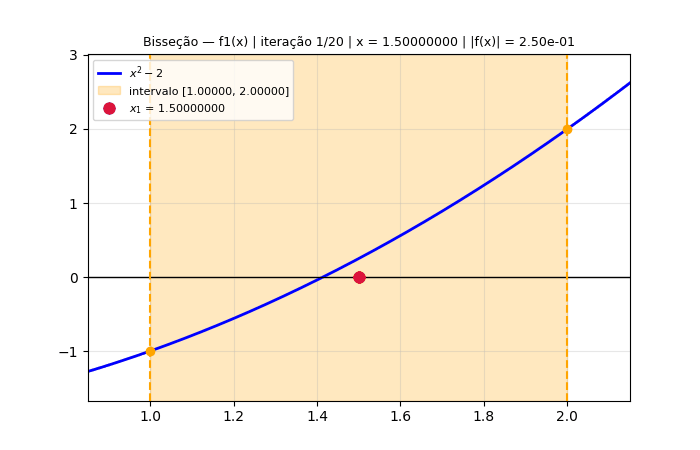

In [ ]:
animar("f1", "Bisseção", resultados[("f1", "Bisseção")], "bissecao_f1.gif", fps=2)

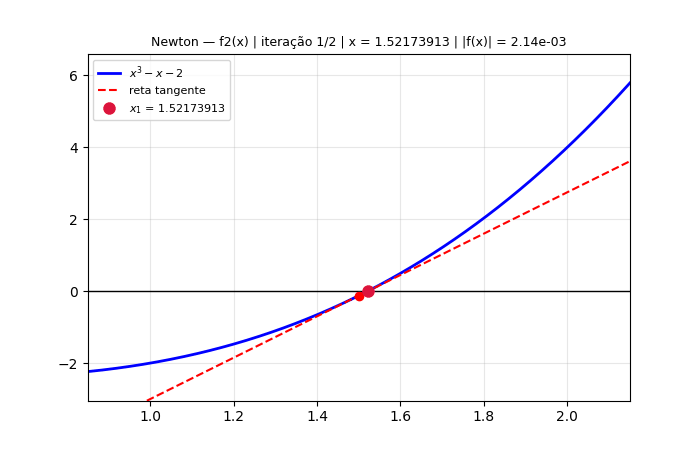

In [ ]:
animar("f2", "Newton", resultados[("f2", "Newton")], "newton_f2.gif", xlim=(1, 2))

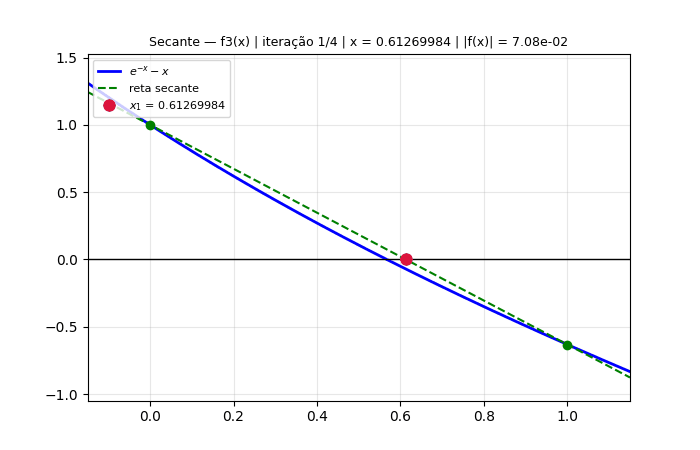

In [ ]:
animar("f3", "Secante", resultados[("f3", "Secante")], "secante_f3.gif")

Caso de falha: Newton em $f_4$ com $x_0=0$ (ciclo). Mostramos só as 8 primeiras iterações.

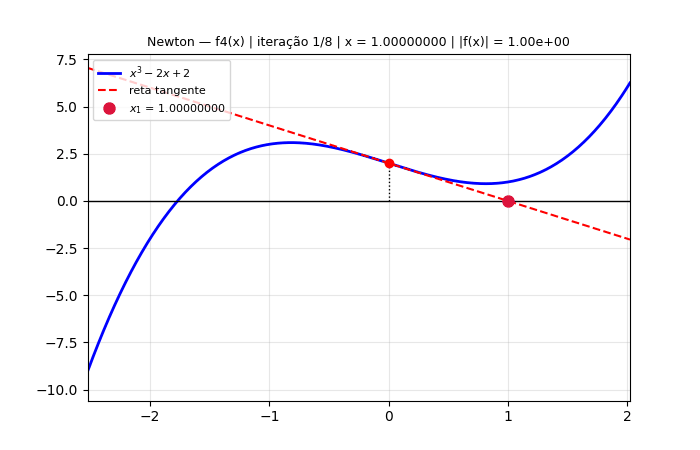

In [ ]:
r = resultados[("f4", "Newton", "0")]
r_curto = dict(r, passos=r["passos"][:8])
animar("f4", "Newton", r_curto, "newton_f4_ciclo.gif", xlim=(-2, 1.5))

### Baixar os GIFs e a tabela (Colab)

In [ ]:
try:
    from google.colab import files
    for arq in ["bissecao_f1.gif", "newton_f2.gif", "secante_f3.gif", "newton_f4_ciclo.gif", "tabela_resultados.csv"]:
        files.download(arq)
except ImportError:
    print("Fora do Colab: os arquivos foram salvos na pasta atual.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Análise dos resultados

- **Todos os métodos convergiram** para os valores iniciais sugeridos:
  $f_1$: $\sqrt 2 \approx 1{,}41421356$; $f_2$: $\approx 1{,}52137971$; $f_3$: $\approx 0{,}56714329$; $f_4$: $\approx -1{,}76929235$.
- **Bisseção** foi sempre o mais lento (≈ 20 iterações), pois o erro cai só pela metade a cada passo
  (convergência linear, $\frac{b-a}{2^k} < 10^{-6} \Rightarrow k \approx 20$). Em compensação, **sempre converge**
  quando $f(a)f(b)<0$ e $f$ é contínua.
- **Newton** foi o mais rápido (2–4 iterações), graças à convergência **quadrática**: o número de casas
  corretas praticamente dobra a cada iteração. Porém exige a derivada e depende muito de $x_0$:
  em $f_4$ com $x_0 = 0$ ele fica preso no ciclo $0 \to 1 \to 0$ e falha após 100 iterações;
  com $x_0$ onde $f'(x_0)=0$ ele nem consegue dar o primeiro passo.
- **Secante** ficou entre os dois (4–6 iterações, ordem ≈ 1,618) e não precisa da derivada,
  mas, como Newton, não tem garantia de convergência e pode falhar se $f(x_k) \approx f(x_{k-1})$.
- Os resíduos $|f(x)|$ finais ficaram abaixo de $10^{-6}$ (em Newton/secante, muitas vezes bem abaixo, pela
  convergência rápida no último passo).

**Conclusão:** a bisseção é robusta porém lenta; Newton é o mais rápido, mas sensível ao chute inicial e
precisa de $f'$; a secante é um bom meio-termo. Na prática, é comum usar a bisseção para aproximar a raiz
e depois refinar com Newton ou secante.